Install & imports

In [1]:

!pip install -q pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, balanced_accuracy_score,
    roc_auc_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)


Load dataset

In [2]:
FILE_PATH = "Peoples_Climate_Vote_Database_2024.csv"  # change if needed

df_raw = pd.read_csv(FILE_PATH)
print(df_raw.shape)
df_raw.head()

(45784, 17)


,Column1,ID,CID,QID,RID,EID,AID,Country,Question Text,Question Text (Short),Response,Education,Age,Weighted Mean,Cat ID,Category,Question Context
0,60,60,1,13,1,1,1,Global,Should countries work together on climate chan...,Countries working together,Yes - they should work together despite their ...,All Education,All Ages,86.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
1,61,61,1,13,2,1,1,Global,Should countries work together on climate chan...,Countries working together,No - they should work separately,All Education,All Ages,7.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
2,62,62,1,13,3,1,1,Global,Should countries work together on climate chan...,Countries working together,It doesn't matter - no country should work on ...,All Education,All Ages,5.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
3,63,63,1,13,1000,1,1,Global,Should countries work together on climate chan...,Countries working together,Don't know,All Education,All Ages,2.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...
4,273,273,1,13,1,1,2,Global,Should countries work together on climate chan...,Countries working together,Yes - they should work together despite their ...,All Education,Under 18,86.0,4,Peoples' call for collaboration,Climate change is a global problem that requir...


Basic structure & columns

In [3]:
print(df_raw.columns)
df_raw.info()

print("\nUnique ages:", df_raw["Age"].unique())
print("Unique education:", df_raw["Education"].unique())
print("Number of countries:", df_raw["Country"].nunique())


Index(['Column1', 'ID', 'CID', 'QID', 'RID', 'EID', 'AID', 'Country',
       'Question Text', 'Question Text (Short)', 'Response', 'Education',
       'Age', 'Weighted Mean', 'Cat ID', 'Category', 'Question Context'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45784 entries, 0 to 45783
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Column1                45784 non-null  int64  
 1   ID                     45784 non-null  int64  
 2   CID                    45784 non-null  int64  
 3   QID                    45784 non-null  int64  
 4   RID                    45784 non-null  int64  
 5   EID                    45784 non-null  int64  
 6   AID                    45784 non-null  int64  
 7   Country                45784 non-null  object 
 8   Question Text          45784 non-null  object 
 9   Question Text (Short)  45784 non-null  object 
 10  Response              

PART A – Predictive Modelling

Target: “High” vs “moderate/low” support for strengthening climate commitments.

Because every age–country group has >50% wanting to strengthen commitments, a simple “support vs not support” label is useless (all 1’s). So we instead predict:

1 = High support (≥ 80% strengthen)
0 = Lower support (< 80%)

You explain this in your report as a methodological choice.

Subset to age-specific rows, all education

In [4]:
df_age = df_raw[
    (df_raw["Education"] == "All Education") &
    (df_raw["Age"] != "All Ages")
].copy()

print(df_age.shape)
df_age["Age"].value_counts()


(20661, 17)


,count
Age,
18 to 35,5183
36 to 59,5183
60 plus,5183
Under 18,5112


We’ll use:

Q9: commitments (target)

Q10: fossil fuels (speed of transition)

Q3: worry about next generation

Q4: experienced extreme weather

Q6: how well country is addressing climate change

Q7: how well big businesses are addressing climate change

Q11: nature protection

In [5]:
# mapping QID to meaning for clarity (from dataset)
qids_used = {
    9:  "commitments",
    10: "fossil_transition",
    3:  "worry_next_generation",
    4:  "extreme_weather_experience",
    6:  "trust_country",
    7:  "trust_business",
    11: "protect_nature"
}

df_model = df_age[df_age["QID"].isin(qids_used.keys())].copy()
print(df_model["QID"].value_counts().sort_index())


QID
3     1746
4     1164
6     1746
7     1746
9     1164
10    1455
11    1164
Name: count, dtype: int64


Pivot to wide format (one row = Country + Age)

In [6]:
df_model["QR"] = df_model["QID"].astype(str) + "_" + df_model["Response"]

wide = df_model.pivot_table(
    index=["Country", "Age"],
    columns="QR",
    values="Weighted Mean"
)

print(wide.shape)
wide.head()


(147, 35)


QR                    10_Don't know  10_Not at all  10_Slowly  \
Country     Age                                                 
Afghanistan 18 to 35            7.0            4.0       39.0   
            36 to 59           14.0            1.0       44.0   
Algeria     18 to 35            7.0           10.0       10.0   
            36 to 59           10.0            8.0       11.0   
Argentina   18 to 35            9.0            6.0       14.0   

QR                    10_Somewhat quickly  10_Very quickly  11_A little  \
Country     Age                                                           
Afghanistan 18 to 35                 11.0             39.0          6.0   
            36 to 59                  9.0             31.0          5.0   
Algeria     18 to 35                 24.0             49.0          5.0   
            36 to 59                 18.0             52.0          2.0   
Argentina   18 to 35                 48.0             24.0          5.0   

QR                    11_A lot  11_Don't know  11_Not at all  3_Don't know  \
Country     Age                                                              
Afghanistan 18 to 35      90.0            2.0            2.0           4.0   
            36 to 59      93.0            2.0            1.0           5.0   
Algeria     18 to 35      93.0            1.0            2.0           2.0   
            36 to 59      96.0            0.0            2.0           4.0   
Argentina   18 to 35      94.0            0.0            1.0           0.0   

QR                    3_Extremely  3_Not at all  3_Not very  3_Somewhat  \
Country     Age                                                           
Afghanistan 18 to 35         32.0           5.0         1.0        22.0   
            36 to 59         33.0           2.0         2.0        19.0   
Algeria     18 to 35         19.0          15.0         9.0        34.0   
            36 to 59         23.0          13.0         9.0        22.0   
Argentina   18 to 35          8.0           6.0        12.0        44.0   

QR                    3_Very  4_About the same as usual  4_Better than usual  \
Country     Age                                                                
Afghanistan 18 to 35    36.0                       26.0                 13.0   
            36 to 59    39.0                       18.0                 15.0   
Algeria     18 to 35    22.0                       22.0                  8.0   
            36 to 59    28.0                       15.0                  8.0   
Argentina   18 to 35    30.0                       41.0                  3.0   

QR                    4_Don't know  4_Worse than usual  6_Don't know  \
Country     Age                                                        
Afghanistan 18 to 35          11.0                50.0           9.0   
            36 to 59          11.0                55.0          14.0   
Algeria     18 to 35           1.0                70.0           7.0   
            36 to 59           1.0                76.0          13.0   
Argentina   18 to 35           0.0                56.0           6.0   

QR                    6_Neither well nor badly  6_Somewhat badly  \
Country     Age                                                    
Afghanistan 18 to 35                      20.0               9.0   
            36 to 59                      23.0               8.0   
Algeria     18 to 35                      45.0              17.0   
            36 to 59                      42.0              16.0   
Argentina   18 to 35                      29.0              37.0   

QR                    6_Somewhat well  6_Very badly  6_Very well  \
Country     Age                                                    
Afghanistan 18 to 35             27.0          17.0         19.0   
            36 to 59             23.0          17.0         15.0   
Algeria     18 to 35             14.0          12.0          4.0   
            36 to 59             16.0           7.0          7

Check missing values:

In [30]:
print("Total NaNs in wide table:", wide.isna().sum().sum())
wide.isna().sum().sort_values(ascending=False).head(10)


Total NaNs in wide table: 0


,0
QR,
10_Don't know,0
10_Not at all,0
10_Slowly,0
10_Somewhat quickly,0
10_Very quickly,0
11_A little,0
11_A lot,0
11_Don't know,0
11_Not at all,0


Creating target variable: high vs lower support

In [7]:
# checking what responses exist for Q9
[val for val in wide.columns if val.startswith("9_")]


["9_Don't know", '9_Keep them the same', '9_Strengthen', '9_Weaken']

In [8]:
# percentage supporting "Strengthen"
wide["support_strengthen_pct"] = wide["9_Strengthen"]

# because everyone > 50, we create "high" vs "lower" support
wide["support_high"] = (wide["support_strengthen_pct"] >= 80).astype(int)

print(wide["support_high"].value_counts())
print(wide["support_strengthen_pct"].describe())


support_high
1    97
0    50
Name: count, dtype: int64
count    147.000000
mean      83.374150
std        9.371489
min       56.000000
25%       77.000000
50%       85.000000
75%       90.000000
max       99.000000
Name: support_strengthen_pct, dtype: float64


Because all age–country groups recorded >50% favouring strengthened commitments, a binary ‘support vs opposition’ target was degenerate. We therefore redefined the outcome as ‘high support’ (≥ 80% of respondents favouring strengthening) vs ‘lower support’ (< 80%).

Feature engineering

We avoid focusing only on “Very quickly” by combining categories into indices:

Energy transition index:

fast = Very quickly + Somewhat quickly

slow = Slowly + Not at all

Worry index:

high_worry = Extremely + Very + Somewhat

low_worry = Not very + Not at all

Trust indices:

trust_country_high = Very well + Somewhat well

trust_business_high = Very well + Somewhat well

Nature protection:

protect_high = A lot

Extreme weather:

extreme_worse = Worse than usual

In [9]:
# helper function to safely sum columns
def sum_cols(df, cols):
    existing = [c for c in cols if c in df.columns]
    if not existing:
        return pd.Series(np.nan, index=df.index)
    return df[existing].sum(axis=1)

features = pd.DataFrame(index=wide.index)

# energy transition
features["fast_transition"] = sum_cols(
    wide,
    ["10_Very quickly", "10_Somewhat quickly"]
)
features["slow_transition"] = sum_cols(
    wide,
    ["10_Slowly", "10_Not at all"]
)
features["fast_minus_slow"] = features["fast_transition"] - features["slow_transition"]

# worry about next generation
features["worry_high"] = sum_cols(
    wide,
    ["3_Extremely", "3_Very", "3_Somewhat"]
)
features["worry_low"] = sum_cols(
    wide,
    ["3_Not very", "3_Not at all"]
)
features["worry_balance"] = features["worry_high"] - features["worry_low"]

# extreme weather
features["extreme_worse"] = wide.get("4_Worse than usual", np.nan)

# trust in country & business
features["trust_country_high"] = sum_cols(
    wide,
    ["6_Very well", "6_Somewhat well"]
)
features["trust_business_high"] = sum_cols(
    wide,
    ["7_Very well", "7_Somewhat well"]
)

# nature protection
features["protect_high"] = wide.get("11_A lot", np.nan)

# age as an ordinal variable
age_order = {"Under 18": 0, "18 to 35": 1, "36 to 59": 2, "60 plus": 3}
features["age_code"] = [age_order[a] for a in wide.index.get_level_values("Age")]

# attach target
features["support_high"] = wide["support_high"]

features.head()


fast_transition  slow_transition  fast_minus_slow  \
Country     Age                                                           
Afghanistan 18 to 35             50.0             43.0              7.0   
            36 to 59             40.0             45.0             -5.0   
Algeria     18 to 35             73.0             20.0             53.0   
            36 to 59             70.0             19.0             51.0   
Argentina   18 to 35             72.0             20.0             52.0   

                      worry_high  worry_low  worry_balance  extreme_worse  \
Country     Age                                                             
Afghanistan 18 to 35        90.0        6.0           84.0           50.0   
            36 to 59        91.0        4.0           87.0           55.0   
Algeria     18 to 35        75.0       24.0           51.0           70.0   
            36 to 59        73.0       22.0           51.0           76.0   
Argentina   18 to 35        82.0       18.0           64.0           56.0   

                      trust_country_high  trust_business_high  protect_high  \
Country     Age                                                               
Afghanistan 18 to 35                46.0                 50.0          90.0   
            36 to 59                38.0                 46.0          93.0   
Algeria     18 to 35                18.0                 12.0          93.0   
            36 to 59                23.0                 13.0          96.0   
Argentina   18 to 35                16.0                 20.0          94.0   

                      age_code  support_high  
Country     Age                               
Afghanistan 18 to 35         1             0  
            36 to 59         2             0  
Algeria     18 to 35         1             0  
            36 to 59         2             0  
Argentina   18 to 35         1             1

In [29]:
mod_data.shape
mod_data.index.to_frame().head()


Country       Age
Country     Age                            
Afghanistan 18 to 35  Afghanistan  18 to 35
            36 to 59  Afghanistan  36 to 59
Algeria     18 to 35      Algeria  18 to 35
            36 to 59      Algeria  36 to 59
Argentina   18 to 35    Argentina  18 to 35

In [10]:
print("NaNs per column:")
print(features.isna().sum())

# droping rows with any missing value (listwise deletion)
mod_data = features.dropna().copy()
print("\nFinal modelling rows:", mod_data.shape[0])

# count of unique countries and ages remain
idx = mod_data.index.to_frame(index=False)
print("Countries in modelling set:", idx["Country"].nunique())
print("Age distribution:\n", idx["Age"].value_counts())


NaNs per column:
fast_transition        0
slow_transition        0
fast_minus_slow        0
worry_high             0
worry_low              0
worry_balance          0
extreme_worse          0
trust_country_high     0
trust_business_high    0
protect_high           0
age_code               0
support_high           0
dtype: int64

Final modelling rows: 147
Countries in modelling set: 65
Age distribution:
 Age
36 to 59    65
18 to 35    63
60 plus     18
Under 18     1
Name: count, dtype: int64


How many rows/countries remained and that we used listwise deletion for missing attitude features (no imputation).

Train/test split

In [11]:
X = mod_data.drop(columns=["support_high"])
y = mod_data["support_high"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Class balance in y_train:\n", y_train.value_counts(normalize=True))


Train size: 110
Test size: 37
Class balance in y_train:
 support_high
1    0.663636
0    0.336364
Name: proportion, dtype: float64


Scaling and models

We’ll compare Logistic Regression vs Random Forest.

In [12]:
# standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1) logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2) random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)  # tree-based models don't need scaling


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Evaluation helper

In [17]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n=== {name} ===")

    metrics = {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
    }

    if y_proba is not None:
        metrics["ROC AUC"] = roc_auc_score(y_te, y_proba)

    for k, v in metrics.items():
        print(f"{k}: {round(v,3)}")

    print("\nConfusion matrix:")
    print(confusion_matrix(y_te, y_pred))

    print("\nClassification report:")
    print(classification_report(y_te, y_pred, zero_division=0))


Compare models

In [18]:
# logistic Regression (scaled)
evaluate_model(
    "Logistic Regression",
    log_reg,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
)

# random Forest (unscaled)
evaluate_model(
    "Random Forest",
    rf,
    X_train, X_test,
    y_train, y_test
)



=== Logistic Regression ===
Accuracy: 0.838
Balanced Accuracy: 0.84
Precision: 0.909
Recall: 0.833
F1: 0.87
ROC AUC: 0.936

Confusion matrix:
[[11  2]
 [ 4 20]]

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79        13
           1       0.91      0.83      0.87        24

    accuracy                           0.84        37
   macro avg       0.82      0.84      0.83        37
weighted avg       0.85      0.84      0.84        37


=== Random Forest ===
Accuracy: 0.784
Balanced Accuracy: 0.728
Precision: 0.786
Recall: 0.917
F1: 0.846
ROC AUC: 0.84

Confusion matrix:
[[ 7  6]
 [ 2 22]]

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.54      0.64        13
           1       0.79      0.92      0.85        24

    accuracy                           0.78        37
   macro avg       0.78      0.73      0.74        37
weighted avg       0.78      0.78 

The model performs better on balanced accuracy / F1,

Due to slightly imbalanced classes you rely more on balanced accuracy and F1 than raw accuracy.

Feature importance / interpretation

In [19]:
feature_names = X.columns

coef = pd.Series(log_reg.coef_[0], index=feature_names).sort_values(ascending=False)
print("Logistic regression coefficients (sorted):")
coef


Logistic regression coefficients (sorted):


,0
trust_country_high,0.761549
extreme_worse,0.686013
worry_high,0.629769
protect_high,0.522696
fast_transition,0.384010
worry_low,0.291658
worry_balance,0.179667
fast_minus_slow,0.166280
slow_transition,0.061756
trust_business_high,-0.340795


In [20]:
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Random Forest feature importances:")
rf_importance


Random Forest feature importances:


,0
protect_high,0.160694
extreme_worse,0.127122
fast_minus_slow,0.113757
fast_transition,0.091851
trust_country_high,0.087714
slow_transition,0.083593
worry_high,0.079026
trust_business_high,0.076447
worry_balance,0.073322
worry_low,0.068987


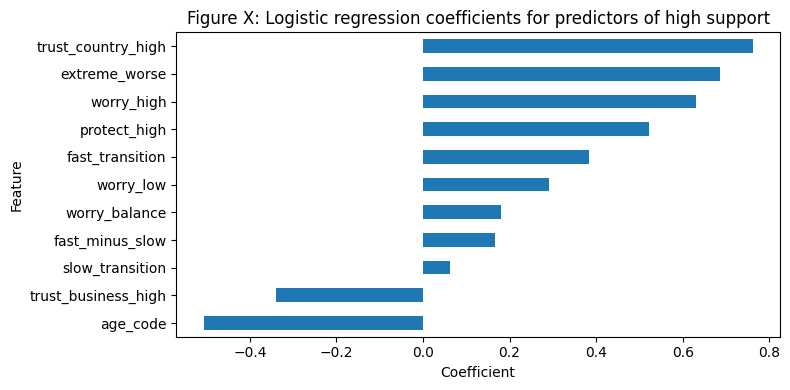

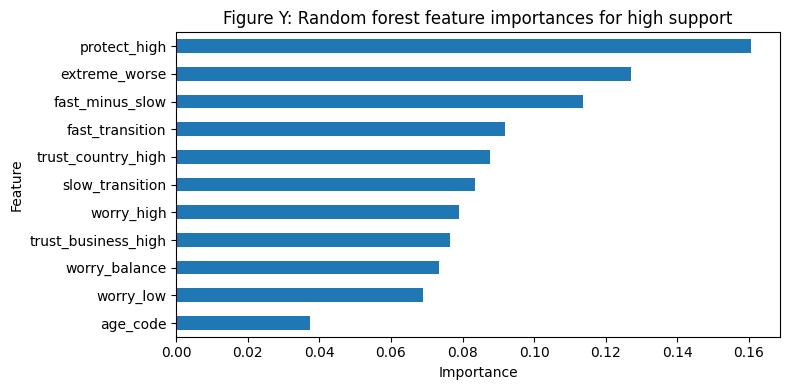

In [21]:
plt.figure(figsize=(8, 4))
coef.sort_values().plot(kind="barh")
plt.ylabel("Feature")
plt.xlabel("Coefficient")
plt.title("Figure X: Logistic regression coefficients for predictors of high support")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
rf_importance.sort_values().plot(kind="barh")
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.title("Figure Y: Random forest feature importances for high support")
plt.tight_layout()
plt.show()


PART B – Clustering Analysis (Country Typologies)

Goal: Typology of countries based on aggregated climate attitudes.

We use “All Ages” + “All Education” so the unit is simply country.

Build country-level dataset

In [22]:
df_country = df_raw[
    (df_raw["Age"] == "All Ages") &
    (df_raw["Education"] == "All Education") &
    (df_raw["QID"].isin(qids_used.keys()))
].copy()

print(df_country.shape)
print("Countries:", df_country["Country"].nunique())

# Pivot
df_country["QR"] = df_country["QID"].astype(str) + "_" + df_country["Response"]
wide_country = df_country.pivot_table(
    index="Country",
    columns="QR",
    values="Weighted Mean"
)

print(wide_country.shape)
print("Missing values:", wide_country.isna().sum().sum())
wide_country.head()


(2555, 17)
Countries: 73
(73, 35)
Missing values: 0


QR,10_Don't know,10_Not at all,10_Slowly,10_Somewhat quickly,10_Very quickly,11_A little,11_A lot,11_Don't know,11_Not at all,3_Don't know,3_Extremely,3_Not at all,3_Not very,3_Somewhat,3_Very,4_About the same as usual,4_Better than usual,4_Don't know,4_Worse than usual,6_Don't know,6_Neither well nor badly,6_Somewhat badly,6_Somewhat well,6_Very badly,6_Very well,7_Don't know,7_Neither well nor badly,7_Somewhat badly,7_Somewhat well,7_Very badly,7_Very well,9_Don't know,9_Keep them the same,9_Strengthen,9_Weaken
Country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,9.0,3.0,40.0,11.0,37.0,5.0,91.0,2.0,2.0,4.0,33.0,5.0,2.0,21.0,36.0,23.0,15.0,10.0,52.0,11.0,21.0,9.0,25.0,17.0,17.0,8.0,18.0,10.0,25.0,16.0,23.0,9.0,14.0,75.0,3.0
Algeria,9.0,10.0,11.0,19.0,51.0,3.0,95.0,0.0,2.0,3.0,21.0,17.0,9.0,26.0,24.0,17.0,8.0,0.0,74.0,9.0,44.0,16.0,16.0,9.0,6.0,23.0,35.0,17.0,11.0,12.0,2.0,4.0,6.0,75.0,15.0
Argentina,8.0,4.0,15.0,46.0,27.0,5.0,94.0,0.0,1.0,0.0,10.0,5.0,11.0,38.0,35.0,37.0,3.0,0.0,60.0,10.0,26.0,35.0,15.0,13.0,1.0,14.0,25.0,29.0,14.0,17.0,1.0,9.0,7.0,83.0,1.0
Australia,4.0,13.0,14.0,25.0,44.0,16.0,76.0,4.0,4.0,1.0,18.0,13.0,13.0,26.0,29.0,53.0,7.0,3.0,37.0,11.0,20.0,20.0,21.0,15.0,13.0,13.0,19.0,18.0,17.0,21.0,12.0,6.0,9.0,74.0,11.0
Bangladesh,4.0,1.0,24.0,15.0,56.0,8.0,92.0,0.0,0.0,1.0,6.0,11.0,10.0,38.0,33.0,16.0,18.0,0.0,66.0,1.0,25.0,8.0,35.0,6.0,25.0,5.0,26.0,15.0,32.0,7.0,15.0,1.0,11.0,86.0,3.0


(This will typically have 73 countries × ~35 columns with no missing values.)

In [23]:
country_features = pd.DataFrame(index=wide_country.index)

# Energy transition
country_features["fast_transition"] = sum_cols(
    wide_country,
    ["10_Very quickly", "10_Somewhat quickly"]
)
country_features["slow_transition"] = sum_cols(
    wide_country,
    ["10_Slowly", "10_Not at all"]
)
country_features["fast_minus_slow"] = country_features["fast_transition"] - country_features["slow_transition"]

# Worry
country_features["worry_high"] = sum_cols(
    wide_country,
    ["3_Extremely", "3_Very", "3_Somewhat"]
)
country_features["worry_low"] = sum_cols(
    wide_country,
    ["3_Not very", "3_Not at all"]
)
country_features["worry_balance"] = country_features["worry_high"] - country_features["worry_low"]

# Extreme weather
country_features["extreme_worse"] = wide_country.get("4_Worse than usual", np.nan)

# Trust
country_features["trust_country_high"] = sum_cols(
    wide_country,
    ["6_Very well", "6_Somewhat well"]
)
country_features["trust_business_high"] = sum_cols(
    wide_country,
    ["7_Very well", "7_Somewhat well"]
)

# Nature
country_features["protect_high"] = wide_country.get("11_A lot", np.nan)

country_features.head()


,fast_transition,slow_transition,fast_minus_slow,worry_high,worry_low,worry_balance,extreme_worse,trust_country_high,trust_business_high,protect_high
Country,,,,,,,,,,
Afghanistan,48.0,43.0,5.0,90.0,7.0,83.0,52.0,42.0,48.0,91.0
Algeria,70.0,21.0,49.0,71.0,26.0,45.0,74.0,22.0,13.0,95.0
Argentina,73.0,19.0,54.0,83.0,16.0,67.0,60.0,16.0,15.0,94.0
Australia,69.0,27.0,42.0,73.0,26.0,47.0,37.0,34.0,29.0,76.0
Bangladesh,71.0,25.0,46.0,77.0,21.0,56.0,66.0,60.0,47.0,92.0


Standardise & PCA for visualisation

In [24]:
scaler_clust = StandardScaler()
X_country = scaler_clust.fit_transform(country_features)

# PCA to 2D for plotting & to reduce noise
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_country)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.37538394 0.30319675]


Choose k (elbow + silhouette)

Inertia: {2: 563.1799979028824, 3: 431.66300341324177, 4: 363.8306698649214, 5: 321.9634647710879, 6: 288.42476527845855}
Silhouette: {2: np.float64(0.2062387873867345), 3: np.float64(0.23883124749194773), 4: np.float64(0.19374875574210296), 5: np.float64(0.20849295032530665), 6: np.float64(0.2198055005024427)}


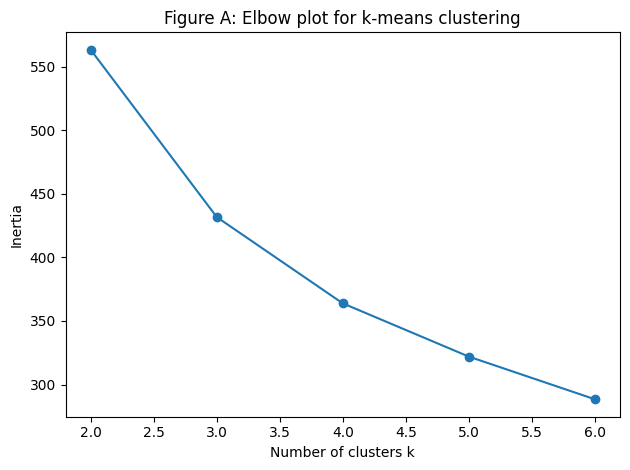

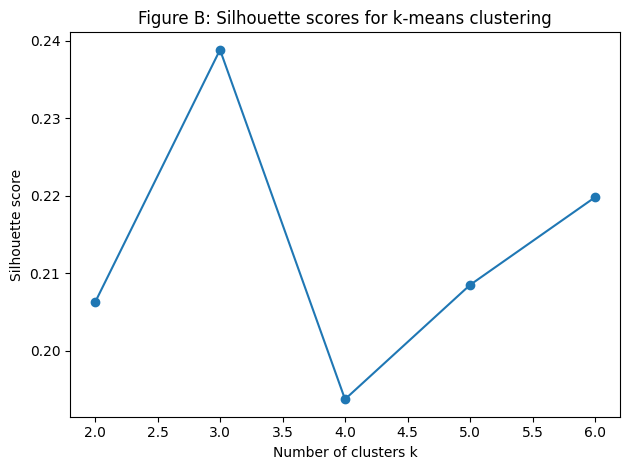

In [25]:
inertias = []
sil_scores = []

ks = range(2, 7)
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_country)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_country, labels))

print("Inertia:", dict(zip(ks, inertias)))
print("Silhouette:", dict(zip(ks, sil_scores)))

# Plot elbow
plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Figure A: Elbow plot for k-means clustering")
plt.tight_layout()
plt.show()

# Plot silhouette
plt.figure()
plt.plot(ks, sil_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Figure B: Silhouette scores for k-means clustering")
plt.tight_layout()
plt.show()


We have to pick one pick one k (e.g. k=3 or k=4) and justify choice using these plots + silhouette.

Final k-means model & cluster interpretation

Let's assume and choose k = 3 .

In [26]:
BEST_K = 3  # adjust based on Cell 17 results

kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
country_clusters = kmeans_final.fit_predict(X_country)

clusters_df = country_features.copy()
clusters_df["cluster"] = country_clusters

clusters_df.groupby("cluster").mean()


,fast_transition,slow_transition,fast_minus_slow,worry_high,worry_low,worry_balance,extreme_worse,trust_country_high,trust_business_high,protect_high
cluster,,,,,,,,,,
0,74.700000,20.650000,54.050000,71.800000,26.000000,45.800000,43.100000,55.750000,42.200000,83.200000
1,73.939394,21.151515,52.787879,87.424242,11.484848,75.939394,54.939394,31.181818,26.121212,88.030303
2,48.700000,45.550000,3.150000,80.900000,17.750000,63.150000,46.650000,39.400000,31.500000,80.350000


In [27]:
for c in sorted(clusters_df["cluster"].unique()):
    print(f"\n=== Cluster {c} ===")
    print(clusters_df[clusters_df["cluster"] == c].index.tolist())



=== Cluster 0 ===
['Australia', 'Bangladesh', 'Barbados', 'Burkina Faso', 'China', 'Comoros (the)', 'Egypt', 'Ethiopia', 'Ghana', 'Global', 'India', 'Jordan', 'Kyrgyzstan', 'Mozambique', 'Niger (the)', 'Nigeria', 'Pakistan', 'Saudi Arabia', 'South Africa', 'Tunisia']

=== Cluster 1 ===
['Algeria', 'Argentina', 'Bhutan', 'Brazil', 'Cambodia', 'Colombia', 'Ecuador', 'El Salvador', 'Fiji', 'France', 'Germany', 'Greece', 'Guatemala', 'Haiti', 'Honduras', 'Iran (Islamic Republic of)', 'Italy', 'Japan', 'Kenya', 'Mexico', 'Myanmar', 'Nepal', 'Nicaragua', 'Paraguay', 'Peru', 'Republic of Korea (the)', 'Romania', 'Solomon Islands', 'Spain', 'Sri Lanka', 'Sudan (the)', 'United Kingdom of Great Britain and Northern Ireland (the)', 'Zimbabwe']

=== Cluster 2 ===
['Afghanistan', 'Benin', 'Canada', 'Czechia', "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Dominican Republic (the)', 'Indonesia', 'Iraq', 'Lao PDR', 'Madagascar', 'Morocco', 'Papua New Guinea', 'Philippines (the)', 'Russian Fed

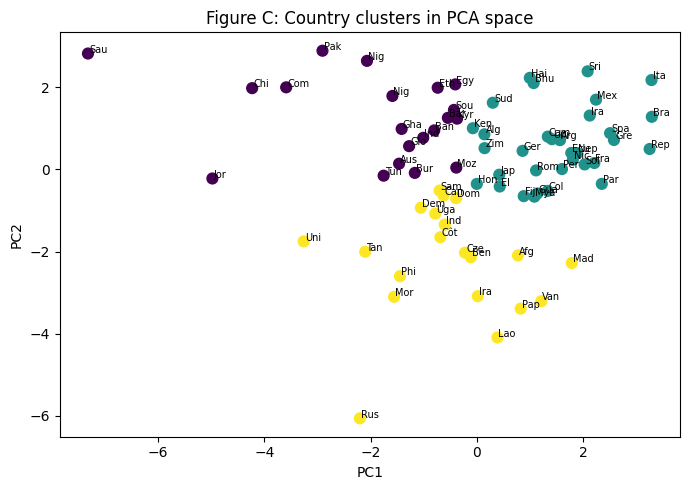

In [28]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=country_clusters,
    s=60
)

for i, country in enumerate(country_features.index):
    plt.text(
        X_pca[i, 0] + 0.02,
        X_pca[i, 1] + 0.02,
        country[:3],  # 3-letter label
        fontsize=7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Figure C: Country clusters in PCA space")
plt.tight_layout()
plt.show()
